In [2]:
!python -m pip install torch torchvision


  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached setuptools-80.10.2-py3-none-any.whl.metadata (6.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.8 MB 960.0 kB/s eta 0:01:59
   ---------------------------------------- 0.1/113.8 MB 1.3 MB/s eta 0:01:28
   ---------------------------------------- 0.2/113.8 MB 1.2 MB/s eta 0:01:33
   ---------------------------------------- 0.2/113.8 MB 1.3 MB/s eta 0:01:31
   ---------------------------------------- 0.3/113.8 MB 1.3 MB/s eta 0:01:30
   ---------------------------------------- 0.3/113.8 MB 1.2 MB/s eta 0:01:33
   ---------------------------------------- 0.4/113.8 MB 1.3 MB/s eta 0:01:29
   ---------------------------------------- 0.5/113.8 MB 1.3 MB/s eta 0:01:29
   ---------------------------------------- 0.5/113.8 MB 1.3 MB/s eta 0:01:29
   --------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!python -m pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
  -f https://data.pyg.org/whl/torch-2.1.0+cpu.html

!python -m pip install torch-geometric


Looking in links: https://data.pyg.org/whl/torch-2.1.0+cpu.html
     ---------------------------------------- 0.0/108.0 kB ? eta -:--:--
     ------- ----------------------------- 20.5/108.0 kB 330.3 kB/s eta 0:00:01
     -------------- ---------------------- 41.0/108.0 kB 393.8 kB/s eta 0:00:01
     ---------------------------------- - 102.4/108.0 kB 737.3 kB/s eta 0:00:01
     ------------------------------------ 108.0/108.0 kB 782.4 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "c:\Users\rzyal\Downloads\CNN-GNN-Kriptogravis\cnn-gnn-kakao\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
          main()
        File "c:\Users\rzyal\Downloads\CNN-GNN-Kriptogravis\cnn-gnn-kakao\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\rzyal\Downloads\CNN-GNN-Kriptogravis\cnn-gnn-kakao\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 118, in get_requires_for_build_wheel
          return hook(config_settings)
                 ^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\rzyal\AppData\Loca


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from torch_geometric.nn import GCNConv
print("PyG OK")


c:\Users\rzyal\Downloads\CNN-GNN-Kriptogravis\cnn-gnn-kakao\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyG OK


In [9]:
# =====================
# CNN-GNN (LOCAL JUPYTER)
# =====================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from torch_geometric.nn import GCNConv

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

# =====================
# CONFIG
# =====================
EPOCHS = 20
BATCH_SIZE = 32
LR = 1e-3
K = 5
DATA_DIR = r'C:\Users\rzyal\Downloads\CNN-GNN-Kriptogravis\cnn-gnn-kakao\data\kakao'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Device:", DEVICE)


Device: cpu


In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
NUM_CLASSES = len(dataset.classes)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

idx = np.arange(len(dataset))
train_idx, temp_idx = train_test_split(
    idx, test_size=0.3, stratify=dataset.targets, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=2/3,
    stratify=np.array(dataset.targets)[temp_idx], random_state=42
)

train_ds = Subset(dataset, train_idx)
val_ds   = Subset(dataset, val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


Classes: ['Sehat', 'VSD']
Total images: 1250


In [11]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)


class CNN_GNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = SimpleCNN()
        self.gcn1 = GCNConv(128, 256)
        self.gcn2 = GCNConv(256, num_classes)

    def forward(self, images, edge_index):
        x = self.cnn(images)
        x = F.relu(self.gcn1(x, edge_index))
        return self.gcn2(x, edge_index)


In [12]:
def build_knn_graph(features, k=5):
    sim = cosine_similarity(features)
    edges = []

    for i in range(len(features)):
        neighbors = np.argsort(sim[i])[-(k+1):]
        for j in neighbors:
            if i != j:
                edges.append([i, j])
                edges.append([j, i])

    return torch.tensor(edges, dtype=torch.long).t().contiguous()


In [13]:
model = CNN_GNN(NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_acc, val_acc = [], []

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.no_grad():
            feats = model.cnn(images).cpu().numpy()
            edge_index = build_knn_graph(feats, K).to(DEVICE)

        out = model(images, edge_index)
        loss = criterion(out, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_acc.append(correct / total)

    # ---- VALIDATION ----
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            feats = model.cnn(images).cpu().numpy()
            edge_index = build_knn_graph(feats, K).to(DEVICE)

            out = model(images, edge_index)
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_acc.append(correct / total)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Acc: {train_acc[-1]:.4f} | "
          f"Val Acc: {val_acc[-1]:.4f}")


Epoch 1/20 | Train Acc: 0.6960 | Val Acc: 0.8400
Epoch 2/20 | Train Acc: 0.8594 | Val Acc: 0.8400
Epoch 3/20 | Train Acc: 0.8777 | Val Acc: 0.8720
Epoch 4/20 | Train Acc: 0.8926 | Val Acc: 0.8720
Epoch 5/20 | Train Acc: 0.8994 | Val Acc: 0.8960
Epoch 6/20 | Train Acc: 0.9074 | Val Acc: 0.9040
Epoch 7/20 | Train Acc: 0.9177 | Val Acc: 0.9280
Epoch 8/20 | Train Acc: 0.9189 | Val Acc: 0.8640
Epoch 9/20 | Train Acc: 0.8983 | Val Acc: 0.9120
Epoch 10/20 | Train Acc: 0.9337 | Val Acc: 0.9360
Epoch 11/20 | Train Acc: 0.9291 | Val Acc: 0.9280
Epoch 12/20 | Train Acc: 0.9337 | Val Acc: 0.9360
Epoch 13/20 | Train Acc: 0.9394 | Val Acc: 0.9280
Epoch 14/20 | Train Acc: 0.9326 | Val Acc: 0.9440
Epoch 15/20 | Train Acc: 0.9451 | Val Acc: 0.9360
Epoch 16/20 | Train Acc: 0.9429 | Val Acc: 0.9360
Epoch 17/20 | Train Acc: 0.9417 | Val Acc: 0.9440
Epoch 18/20 | Train Acc: 0.9497 | Val Acc: 0.9440
Epoch 19/20 | Train Acc: 0.9497 | Val Acc: 0.9520
Epoch 20/20 | Train Acc: 0.9349 | Val Acc: 0.9440


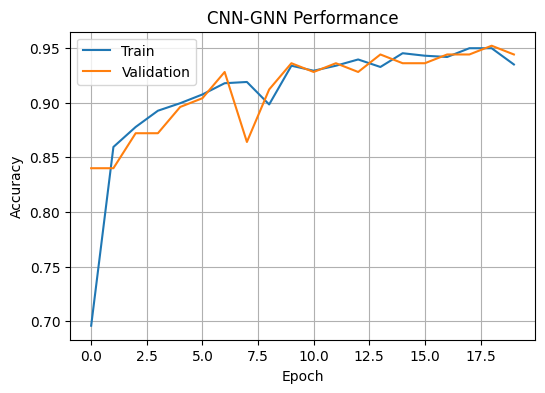

In [14]:
plt.figure(figsize=(6,4))
plt.plot(train_acc, label='Train')
plt.plot(val_acc, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN-GNN Performance')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import numpy as np

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:   # bisa diganti test_loader
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        feats = model.cnn(images).cpu().numpy()
        edge_index = build_knn_graph(feats, K).to(DEVICE)

        outputs = model(images, edge_index)
        probs = torch.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # class VSD


In [16]:
class_names = dataset.classes  # ['Healthy', 'VSD']

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=2
)

print(report)


              precision    recall  f1-score   support

       Sehat       0.94      0.95      0.95        64
         VSD       0.95      0.93      0.94        61

    accuracy                           0.94       125
   macro avg       0.94      0.94      0.94       125
weighted avg       0.94      0.94      0.94       125



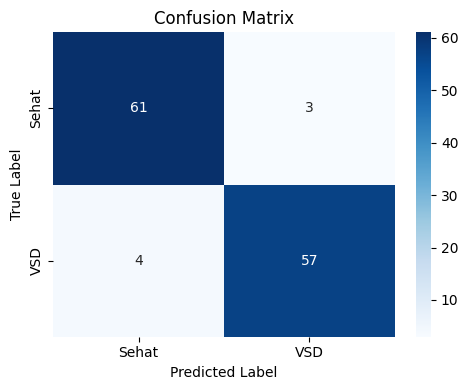

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
class_names = dataset.classes  # ['Healthy', 'VSD']

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


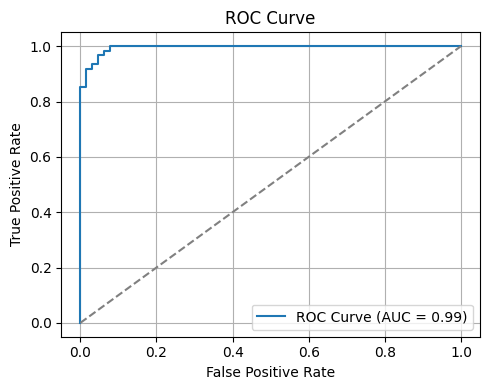

In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
class CNN_Only(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = SimpleCNN()
        self.fc = nn.Linear(128, num_classes)

    def forward(self, images):
        x = self.cnn(images)
        return self.fc(x)


In [21]:
model_cnn = CNN_Only(NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

cnn_train_acc = []
cnn_val_acc = []

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model_cnn.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model_cnn(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    cnn_train_acc.append(correct / total)

    # ---- VALIDATION ----
    model_cnn.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model_cnn(images)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    cnn_val_acc.append(correct / total)

    print(f"[CNN-only] Epoch {epoch+1}/{EPOCHS} | Val Acc: {cnn_val_acc[-1]:.4f}")


[CNN-only] Epoch 1/20 | Val Acc: 0.6400
[CNN-only] Epoch 2/20 | Val Acc: 0.8400
[CNN-only] Epoch 3/20 | Val Acc: 0.8720
[CNN-only] Epoch 4/20 | Val Acc: 0.9280
[CNN-only] Epoch 5/20 | Val Acc: 0.9200
[CNN-only] Epoch 6/20 | Val Acc: 0.9280
[CNN-only] Epoch 7/20 | Val Acc: 0.9520
[CNN-only] Epoch 8/20 | Val Acc: 0.9440
[CNN-only] Epoch 9/20 | Val Acc: 0.9520
[CNN-only] Epoch 10/20 | Val Acc: 0.9680
[CNN-only] Epoch 11/20 | Val Acc: 0.9520
[CNN-only] Epoch 12/20 | Val Acc: 0.9600
[CNN-only] Epoch 13/20 | Val Acc: 0.9680
[CNN-only] Epoch 14/20 | Val Acc: 0.9520
[CNN-only] Epoch 15/20 | Val Acc: 0.9600
[CNN-only] Epoch 16/20 | Val Acc: 0.9600
[CNN-only] Epoch 17/20 | Val Acc: 0.9760
[CNN-only] Epoch 18/20 | Val Acc: 0.9680
[CNN-only] Epoch 19/20 | Val Acc: 0.9520
[CNN-only] Epoch 20/20 | Val Acc: 0.9760


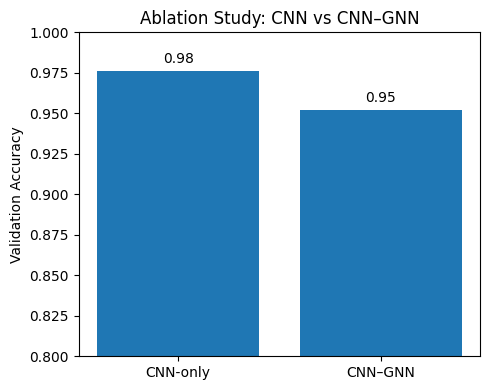

In [ ]:
import matplotlib.pyplot as plt

models = ['CNN-only', 'CNN–GNN']
accuracies = [max(cnn_val_acc), max(val_acc)]

plt.figure(figsize=(5,4))
plt.bar(models, accuracies)
plt.ylabel('Validation Accuracy')
plt.title('Ablation Study: CNN vs CNN–GNN')
plt.ylim(0.8, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()
